 # Session 4: From a messy inbox to executive charts



 **Business request:** Combine five months of expense files from four departments, clean their inconsistent labels, take an audit sample, summarize approved spending, and export English and Korean reports.



 > Run this notebook from the repository root. The data is synthetic.

 ## Before we get started



 1. Add the following python package to your environment (to export notebooks to HTML):

    - `notebook` ---> UV add ----(Python Package name)



 In this class, we use UV for python management. Python packages are installed with 'UV add XXX'



 2. Download the `inbox.zip` dataset from iCampus and save it in the `data/inbox` directory.

    - check if your data folder is being ignored by `.gitignore`

 ## 1. Discover and list the files in the messy inbox

 - More information about the pathlib module: https://medium.com/data-science/why-you-should-start-using-pathlib-as-an-alternative-to-the-os-module-d9eccd994745

In [1]:
## Let's define the location of the data, output, and temporary directories so that we don't need to hardcode and repeat paths throughout the code
from pathlib import Path

data_dir = Path("data/inbox")
output_dir = Path("outputs")
temp_dir = Path("temp")

## Then, let's create the output and temporary directories if they don't already exist

output_dir.mkdir(parents=True, exist_ok=True)
temp_dir.mkdir(parents=True, exist_ok=True)

In [2]:
## Then, let's list all files in the data directory
## show Path(data_dir).iterdir() first for demonstration

list(data_dir.iterdir())

all_files_glob = [str(path) for path in Path(data_dir).iterdir()]

print(all_files_glob)

['data\\inbox\\2026-01_hr_expenses.csv', 'data\\inbox\\2026-01_marketing_expenses.xlsx', 'data\\inbox\\2026-01_operations_expenses.xlsx', 'data\\inbox\\2026-01_sales_expenses.csv', 'data\\inbox\\2026-02_hr_expenses.xlsx', 'data\\inbox\\2026-02_marketing_expenses.csv', 'data\\inbox\\2026-02_operations_expenses.csv', 'data\\inbox\\2026-02_sales_expenses.xlsx', 'data\\inbox\\2026-03_hr_expenses.csv', 'data\\inbox\\2026-03_marketing_expenses.xlsx', 'data\\inbox\\2026-03_operations_expenses.xlsx', 'data\\inbox\\2026-03_sales_expenses.csv', 'data\\inbox\\2026-04_hr_expenses.xlsx', 'data\\inbox\\2026-04_marketing_expenses.csv', 'data\\inbox\\2026-04_operations_expenses.csv', 'data\\inbox\\2026-04_sales_expenses.xlsx', 'data\\inbox\\2026-05_hr_expenses.csv', 'data\\inbox\\2026-05_marketing_expenses.xlsx', 'data\\inbox\\2026-05_operations_expenses.xlsx', 'data\\inbox\\2026-05_sales_expenses.csv', 'data\\inbox\\2026-06_hr_expenses.xlsx', 'data\\inbox\\2026-06_marketing_expenses.csv', 'data\\inbo

In [3]:
all_files_glob

['data\\inbox\\2026-01_hr_expenses.csv',
 'data\\inbox\\2026-01_marketing_expenses.xlsx',
 'data\\inbox\\2026-01_operations_expenses.xlsx',
 'data\\inbox\\2026-01_sales_expenses.csv',
 'data\\inbox\\2026-02_hr_expenses.xlsx',
 'data\\inbox\\2026-02_marketing_expenses.csv',
 'data\\inbox\\2026-02_operations_expenses.csv',
 'data\\inbox\\2026-02_sales_expenses.xlsx',
 'data\\inbox\\2026-03_hr_expenses.csv',
 'data\\inbox\\2026-03_marketing_expenses.xlsx',
 'data\\inbox\\2026-03_operations_expenses.xlsx',
 'data\\inbox\\2026-03_sales_expenses.csv',
 'data\\inbox\\2026-04_hr_expenses.xlsx',
 'data\\inbox\\2026-04_marketing_expenses.csv',
 'data\\inbox\\2026-04_operations_expenses.csv',
 'data\\inbox\\2026-04_sales_expenses.xlsx',
 'data\\inbox\\2026-05_hr_expenses.csv',
 'data\\inbox\\2026-05_marketing_expenses.xlsx',
 'data\\inbox\\2026-05_operations_expenses.xlsx',
 'data\\inbox\\2026-05_sales_expenses.csv',
 'data\\inbox\\2026-06_hr_expenses.xlsx',
 'data\\inbox\\2026-06_marketing_expen

In [4]:
# Filter all file paths in the all_files_glob list to include only CSV and Excel files

data_files = [f for f in all_files_glob if f.endswith(('.csv', '.xlsx'))]

print(data_files)

['data\\inbox\\2026-01_hr_expenses.csv', 'data\\inbox\\2026-01_marketing_expenses.xlsx', 'data\\inbox\\2026-01_operations_expenses.xlsx', 'data\\inbox\\2026-01_sales_expenses.csv', 'data\\inbox\\2026-02_hr_expenses.xlsx', 'data\\inbox\\2026-02_marketing_expenses.csv', 'data\\inbox\\2026-02_operations_expenses.csv', 'data\\inbox\\2026-02_sales_expenses.xlsx', 'data\\inbox\\2026-03_hr_expenses.csv', 'data\\inbox\\2026-03_marketing_expenses.xlsx', 'data\\inbox\\2026-03_operations_expenses.xlsx', 'data\\inbox\\2026-03_sales_expenses.csv', 'data\\inbox\\2026-04_hr_expenses.xlsx', 'data\\inbox\\2026-04_marketing_expenses.csv', 'data\\inbox\\2026-04_operations_expenses.csv', 'data\\inbox\\2026-04_sales_expenses.xlsx', 'data\\inbox\\2026-05_hr_expenses.csv', 'data\\inbox\\2026-05_marketing_expenses.xlsx', 'data\\inbox\\2026-05_operations_expenses.xlsx', 'data\\inbox\\2026-05_sales_expenses.csv', 'data\\inbox\\2026-06_hr_expenses.xlsx', 'data\\inbox\\2026-06_marketing_expenses.csv', 'data\\inbo

In [5]:
## Create DataFrame of Files to get a structured view of all CSV and Excel files
import pandas as pd

files_df = pd.DataFrame({
    'filename': data_files,
    'filetype': ['csv' if f.endswith('.csv') else 'xlsx' for f in data_files]
})

files_df.head()

,filename,filetype
0,data\inbox\2026-01_hr_expenses.csv,csv
1,data\inbox\2026-01_marketing_expenses.xlsx,xlsx
2,data\inbox\2026-01_operations_expenses.xlsx,xlsx
3,data\inbox\2026-01_sales_expenses.csv,csv
4,data\inbox\2026-02_hr_expenses.xlsx,xlsx


In [6]:
## Lets create two lists for each filetype 
csv_files = [f for f in data_files if f.endswith('.csv')]
xlsx_files = [f for f in data_files if f.endswith('.xlsx')]

print("CSV Files:", csv_files)
print("Excel Files:", xlsx_files)

CSV Files: ['data\\inbox\\2026-01_hr_expenses.csv', 'data\\inbox\\2026-01_sales_expenses.csv', 'data\\inbox\\2026-02_marketing_expenses.csv', 'data\\inbox\\2026-02_operations_expenses.csv', 'data\\inbox\\2026-03_hr_expenses.csv', 'data\\inbox\\2026-03_sales_expenses.csv', 'data\\inbox\\2026-04_marketing_expenses.csv', 'data\\inbox\\2026-04_operations_expenses.csv', 'data\\inbox\\2026-05_hr_expenses.csv', 'data\\inbox\\2026-05_sales_expenses.csv', 'data\\inbox\\2026-06_marketing_expenses.csv', 'data\\inbox\\2026-06_operations_expenses.csv']
Excel Files: ['data\\inbox\\2026-01_marketing_expenses.xlsx', 'data\\inbox\\2026-01_operations_expenses.xlsx', 'data\\inbox\\2026-02_hr_expenses.xlsx', 'data\\inbox\\2026-02_sales_expenses.xlsx', 'data\\inbox\\2026-03_marketing_expenses.xlsx', 'data\\inbox\\2026-03_operations_expenses.xlsx', 'data\\inbox\\2026-04_hr_expenses.xlsx', 'data\\inbox\\2026-04_sales_expenses.xlsx', 'data\\inbox\\2026-05_marketing_expenses.xlsx', 'data\\inbox\\2026-05_operat

In [7]:
## Let's print a preview of some CSV files. What is the same? What is different?

csv_preview = pd.read_csv(csv_files[3]) # Try some more by changing th index
csv_preview.head()

,전표번호,사용일,부서,항목,거래처,금액(원),승인상태,사번,내역
0,EX-202602-OP-01,2026-02-11,OPS,소프트웨어,Notion,"649,000",Approved,O153,Software expense
1,EX-202602-OP-02,2026-02-11,운영,Office Supplies,Office Depot,499000,Y,O156,Office Supplies expense
2,EX-202602-OP-03,2026-02-26,운영,SaaS,Slack,897000,Y,O143,Software expense
3,EX-202602-OP-04,2026-02-20,OPS,L&D,Fast Campus,650000,Y,O157,Training expense
4,EX-202602-OP-05,2026-02-19,운영,사무용품,Office Depot,"508,000",Y,O153,Office Supplies expense


In [8]:
## Let's do the same for the Excel files

excel_preview = pd.read_excel(xlsx_files[0])
excel_preview.head()

,Transaction ID,Date,Department,Category,Vendor,Amount KRW,Status,Employee ID,Description
0,EX-202601-MA-01,2026-01-16,Marketing,광고비,Seoul Media Lab,3772000,Y,M113,Advertising expense
1,EX-202601-MA-02,2026-01-01,마케팅,Software,DataCloud Korea,552000,Approved,M115,Software expense
2,EX-202601-MA-03,2026-01-05,마케팅,Business Travel,Kakao T,520000,Approved,M104,Travel expense
3,EX-202601-MA-04,2026-01-22,MKT,출장비,Kakao T,156000,승인,M104,Travel expense
4,EX-202601-MA-05,2026-01-27,마케팅,Food,Baemin,56000,Review,M109,Meals expense


 ## 2. Merging the DataFrames



 `pandas.concat()` function concatenate two or more pandas objects like DataFrames or Series along a particular axis. It is especially useful when combining datasets either vertically (row-wise) or horizontally (column-wise). Read about using conact to append dataframes in pandas: [Future Replacement of the Append Method in Panda Python](https://www.geeksforgeeks.org/python/future-replacement-of-the-append-method-in-panda-python/)

In [9]:
## Append all CSV files into a single DataFrame and then inspect it
csv_combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

print(f"Combined shape: {csv_combined_df.shape}")
csv_combined_df.head()

Combined shape: (272, 36)


,ID,Expense Date,Dept,Cost Category,Merchant,Total,Approved?,Staff ID,Note,expense_id,...,Description,전표번호,사용일,부서,항목,거래처,금액(원),승인상태,사번,내역
0,EX-202601-HR-01,2026-01-13,HR,채용비,Wanted,2003000,Rejected,H163,Recruiting expense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EX-202601-HR-02,2026-01-02,HR,Training,Korea Management Institute,753000,Y,H164,Training expense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EX-202601-HR-03,2026-01-24,HR,Meals,Local Restaurant,207000,Approved,H161,Meals expense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,EX-202601-HR-04,2026-01-02,People,교육비,Coursera,1056000,검토중,H177,Training expense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,EX-202601-HR-05,2026-01-25,HR,교육비,Korea Management Institute,"490,000",Approved,H160,Training expense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
## Check all the columns in the combined DataFrame
csv_combined_df.columns

Index(['ID', 'Expense Date', 'Dept', 'Cost Category', 'Merchant', 'Total',
       'Approved?', 'Staff ID', 'Note', 'expense_id', 'transaction_date',
       'team', 'expense_type', 'supplier', 'amount', 'approval', 'employee',
       'memo', 'Transaction ID', 'Date', 'Department', 'Category', 'Vendor',
       'Amount KRW', 'Status', 'Employee ID', 'Description', '전표번호', '사용일',
       '부서', '항목', '거래처', '금액(원)', '승인상태', '사번', '내역'],
      dtype='str')

 You can find the column mapping for the cell below at https://github.com/pimatskku/BAM5103/blob/main/column_mapping.txt

In [12]:
## Build a mapping table from each department's column names to the canonical schema
# Canonical fields: transaction_id, expense_date, department, category, vendor, amount_krw, approval_status, employee_id, description
column_mapping = {
    # HR convention
    "ID": "transaction_id",
    "Expense Date": "expense_date",
    "Dept": "department",
    "Cost Category": "category",
    "Merchant": "vendor",
    "Total": "amount_krw",
    "Approved?": "approval_status",
    "Staff ID": "employee_id",
    "Note": "description",
    # Sales convention
    "expense_id": "transaction_id",
    "transaction_date": "expense_date",
    "team": "department",
    "expense_type": "category",
    "supplier": "vendor",
    "amount": "amount_krw",
    "approval": "approval_status",
    "employee": "employee_id",
    "memo": "description",
    # Marketing convention
    "Transaction ID": "transaction_id",
    "Date": "expense_date",
    "Department": "department",
    "Category": "category",
    "Vendor": "vendor",
    "Amount KRW": "amount_krw",
    "Status": "approval_status",
    "Employee ID": "employee_id",
    "Description": "description",
    # Operations convention (Korean)
    "전표번호": "transaction_id",
    "사용일": "expense_date",
    "부서": "department",
    "항목": "category",
    "거래처": "vendor",
    "금액(원)": "amount_krw",
    "승인상태": "approval_status",
    "사번": "employee_id",
    "내역": "description",
}


In [13]:
## Read each CSV, rename its columns to the canonical schema, add a source column then combine them all
renamed_csv_dataframes = []

for f in csv_files:
    df = pd.read_csv(f)
    df = df.rename(columns=column_mapping)
    df['source'] = f.split('/')[-1]
    renamed_csv_dataframes.append(df)

csv_combined_df = pd.concat(renamed_csv_dataframes, ignore_index=True)
print(f"Combined CSV shape: {csv_combined_df.shape}")

Combined CSV shape: (272, 10)


In [14]:
## Let's add the Excel files to the combined DataFrame as well
renamed_excel_dataframes = []

for f in xlsx_files:
    df = pd.read_excel(f)
    df = df.rename(columns=column_mapping)
    df['source'] = f.split('/')[-1]
    renamed_excel_dataframes.append(df)

excel_combined_df = pd.concat(renamed_excel_dataframes, ignore_index=True)

print(f"Combined Excel shape: {excel_combined_df.shape}")

all_combined_df = pd.concat([csv_combined_df, excel_combined_df], ignore_index=True)
print(f"All combined shape: {all_combined_df.shape}")



Combined Excel shape: (267, 10)
All combined shape: (539, 10)


 ## 3. Get a sample from the DataFrame



 Pandas `DataFrame.sample()` function is used to select randomly rows or columns from a DataFrame. It proves particularly helpful while dealing with huge datasets where we want to test or analyze a small representative subset. We can define the number or proportion of items to sample and manage randomness through parameters such as n, frac and random_state. [Read more...](https://www.geeksforgeeks.org/python/python-pandas-dataframe-sample/)

In [15]:
## Lets discover the newly merged dataframe by sampling a few rows. What should be fixed next?
all_combined_df.sample(10)

,transaction_id,expense_date,department,category,vendor,amount_krw,approval_status,employee_id,description,source
449,EX-202605-MA-03,2026-05-01 00:00:00,MKT,SaaS,Notion,821000.0,Y,M103,Software expense,data\inbox\2026-05_marketing_expenses.xlsx
429,EX-202604-SA-03,2026-04-17 00:00:00,SLS,Software,DataCloud Korea,135000.0,승인,S134,Software expense,data\inbox\2026-04_sales_expenses.xlsx
399,EX-202604-HR-01,2026-04-02 00:00:00,People,사무용품,Office Depot,320000.0,Y,H168,Office Supplies expense,data\inbox\2026-04_hr_expenses.xlsx
530,EX-202606-SA-17,2026-06-07 00:00:00,Sales,소프트웨어,Slack,591000.0,승인,S128,NaN,data\inbox\2026-06_sales_expenses.xlsx
328,EX-202602-HR-15,2026-02-12 00:00:00,People,교육비,Fast Campus,892000.0,N,H170,Training expense,data\inbox\2026-02_hr_expenses.xlsx
159,EX-202604-OP-04,2026-04-17,Operations,Office Supplies,Alpha Stationery,28000,Approved,O144,Office Supplies expense,data\inbox\2026-04_operations_expenses.csv
175,EX-202604-OP-20,2026-04-02,OPS,L&D,Fast Campus,"165,000",Y,O144,Training expense,data\inbox\2026-04_operations_expenses.csv
316,EX-202602-HR-03,2026-02-16 00:00:00,인사,Meals,Baemin,122000.0,Approved,H177,Meals expense,data\inbox\2026-02_hr_expenses.xlsx
29,EX-202601-SA-07,01/04/2026,영업,식비,Local Restaurant,"56,000",Rejected,S127,Meals expense,data\inbox\2026-01_sales_expenses.csv
16,EX-202601-HR-17,2026-01-12,인사,교육비,Coursera,1566000,Y,H164,Training expense,data\inbox\2026-01_hr_expenses.csv


 https://github.com/pimatskku/BAM5103/blob/main/value_mappings.txt

In [16]:
## Paste value mappings from https://github.com/pimatskku/BAM5103/blob/main/value_mappings.txt below

department_mapping = {
    "Marketing": "Marketing", "MKT": "Marketing", "마케팅": "Marketing",
    "Sales": "Sales", "SLS": "Sales", "영업": "Sales",
    "Operations": "Operations", "OPS": "Operations", "운영": "Operations",
    "HR": "HR", "People": "HR", "인사": "HR",
}

category_mapping = {
    "Advertising": "Advertising", "Ads": "Advertising", "광고비": "Advertising",
    "Software": "Software", "SaaS": "Software", "소프트웨어": "Software",
    "Travel": "Travel", "Business Travel": "Travel", "출장비": "Travel",
    "Meals": "Meals", "Food": "Meals", "식비": "Meals",
    "Client Events": "Client Events", "Events": "Client Events", "고객행사": "Client Events",
    "Office Supplies": "Office Supplies", "Supplies": "Office Supplies", "사무용품": "Office Supplies",
    "Logistics": "Logistics", "Delivery": "Logistics", "물류비": "Logistics",
    "Training": "Training", "L&D": "Training", "교육비": "Training",
    "Recruiting": "Recruiting", "Hiring": "Recruiting", "채용비": "Recruiting",
}

status_mapping = {
    "Approved": "Approved", "Y": "Approved", "승인": "Approved",
    "Pending": "Pending", "Review": "Pending", "검토중": "Pending",
    "Rejected": "Rejected", "N": "Rejected", "반려": "Rejpected",
}

 ## 4. Transforming (mapping) the values in the dataset with our mapping dictionaries



 Pandas is a widely used library for manipulating datasets. There are various in-built functions of pandas, one such function is `pandas.map()`, which is used to map values from two series having one similar column. For mapping two series, the last column of the first should be the same as the index column of the second series, also the values should be unique. [Read more...](https://www.geeksforgeeks.org/python/python-pandas-map/)

In [17]:
## Before we map the values in the dataframe, we create a copy to preserve the original dataframe
transformed_df = all_combined_df.copy()

In [18]:
## Let's transform the values in the dataframe using the mapping dictionaries we created
transformed_df['department'] = transformed_df['department'].map(department_mapping)
transformed_df['category'] = transformed_df['category'].map(category_mapping)
transformed_df['approval_status'] = transformed_df['approval_status'].map(status_mapping)


In [19]:
all_combined_df.sample(5)

all_combined_df['department'].unique()

<StringArray>
[        'HR',     'People',         '인사',        'SLS',         '영업',
      'Sales',        'MKT',        '마케팅',  'Marketing',        'OPS',
         '운영', 'Operations']
Length: 12, dtype: str

In [22]:
## Let's check the first few rows of the transformed dataframe to ensure the mappings were applied correctly
transformed_df.sample(10)

transformed_df['department'].unique() # Checking mapping works or not

<StringArray>
['HR', 'Sales', 'Marketing', 'Operations']
Length: 4, dtype: str

In [23]:
transformed_df['category'].unique()

<StringArray>
[     'Recruiting',        'Training',           'Meals', 'Office Supplies',
          'Travel',        'Software',   'Client Events',     'Advertising',
       'Logistics']
Length: 9, dtype: str

In [26]:
## Export to Excel to have a easier view of the data
transformed_df.to_excel(temp_dir / "combined_data.xlsx")

In [25]:
## A little trick to save Excel files with a timestamp

## Use the timestamp in the filename when exporting to Excel
import datetime
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
transformed_df.to_excel(temp_dir / f"data_{timestamp}.xlsx", index=False)

## Add your temp folder to .gitignore to avoid committing temporary files


 ### Converting Columns to Datetime



 `pandas.to_datetime()` converts argument(s) to datetime. This function is essential for working with date and time data, especially when parsing strings or timestamps into Python's datetime64 format used in Pandas. [Read more](https://www.geeksforgeeks.org/pandas/python-pandas-to_datetime/)

In [27]:
## Let's convert the expense_date column to datetime format
# The "mixed" format allows pandas to infer the datetime format for each entry individually. This is useful when the column contains multiple date formats.
# If a date cannot be parsed, it will be set to NaT (Not a Time) due to errors="coerce".

transformed_df["expense_date"] = pd.to_datetime(transformed_df["expense_date"], format="mixed", errors="coerce")

In [28]:
# Validation

transformed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction_id   539 non-null    str           
 1   expense_date     539 non-null    datetime64[us]
 2   department       539 non-null    str           
 3   category         539 non-null    str           
 4   vendor           539 non-null    str           
 5   amount_krw       538 non-null    object        
 6   approval_status  539 non-null    str           
 7   employee_id      539 non-null    str           
 8   description      506 non-null    str           
 9   source           539 non-null    str           
dtypes: datetime64[us](1), object(1), str(8)
memory usage: 42.2+ KB


In [29]:
## And add at 'month' column to transformed_df 
transformed_df['month'] = transformed_df['expense_date'].dt.month

In [30]:
transformed_df.sample(5)

,transaction_id,expense_date,department,category,vendor,amount_krw,approval_status,employee_id,description,source,month
194,EX-202605-HR-13,2026-05-19,HR,Training,Korea Management Institute,915000,Approved,H164,Training expense,data\inbox\2026-05_hr_expenses.csv,5
293,EX-202601-OP-01,2026-01-15,Operations,Training,Fast Campus,1619000.0,Approved,O142,NaN,data\inbox\2026-01_operations_expenses.xlsx,1
90,EX-202602-OP-20,2026-02-07,Operations,Training,Korea Management Institute,1843000,Pending,O153,Training expense,data\inbox\2026-02_operations_expenses.csv,2
475,EX-202605-OP-05,2026-05-07,Operations,Office Supplies,Coupang Business,176000.0,Approved,O157,Office Supplies expense,data\inbox\2026-05_operations_expenses.xlsx,5
247,EX-202606-OP-01,2026-06-13,Operations,Training,Fast Campus,624000,Approved,O148,Training expense,data\inbox\2026-06_operations_expenses.csv,6


In [31]:
## Let's convert the amount_krw column to numeric values
transformed_df['amount_krw'] = pd.to_numeric(
    transformed_df["amount_krw"].astype("string").str.replace(",", "", regex=False),
    errors="coerce",
)

In [32]:
transformed_df.info() # Validation

<class 'pandas.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction_id   539 non-null    str           
 1   expense_date     539 non-null    datetime64[us]
 2   department       539 non-null    str           
 3   category         539 non-null    str           
 4   vendor           539 non-null    str           
 5   amount_krw       538 non-null    Float64       
 6   approval_status  539 non-null    str           
 7   employee_id      539 non-null    str           
 8   description      506 non-null    str           
 9   source           539 non-null    str           
 10  month            539 non-null    int32         
dtypes: Float64(1), datetime64[us](1), int32(1), str(8)
memory usage: 44.9 KB


In [33]:
transformed_df.sample(5)

,transaction_id,expense_date,department,category,vendor,amount_krw,approval_status,employee_id,description,source,month
517,EX-202606-SA-04,2026-06-10,Sales,Software,DataCloud Korea,724000.0,Approved,S137,Software expense,data\inbox\2026-06_sales_expenses.xlsx,6
386,EX-202603-OP-10,2026-03-13,Operations,Software,Notion,898000.0,Approved,O142,Software expense,data\inbox\2026-03_operations_expenses.xlsx,3
510,EX-202606-HR-18,2026-06-17,HR,Recruiting,JobKorea,772000.0,Approved,H176,Recruiting expense,data\inbox\2026-06_hr_expenses.xlsx,6
132,EX-202603-SA-21,2026-03-20,Sales,Meals,Local Restaurant,93000.0,Approved,S133,Meals expense,data\inbox\2026-03_sales_expenses.csv,3
528,EX-202606-SA-15,2026-06-25,Sales,Meals,Office Cafe,154000.0,Pending,S120,Meals expense,data\inbox\2026-06_sales_expenses.xlsx,6


In [34]:
# Less find out if there are duplicates in the transaction_id column

transformed_df['transaction_id'].duplicated().sum()

np.int64(0)

In [35]:
transformed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction_id   539 non-null    str           
 1   expense_date     539 non-null    datetime64[us]
 2   department       539 non-null    str           
 3   category         539 non-null    str           
 4   vendor           539 non-null    str           
 5   amount_krw       538 non-null    Float64       
 6   approval_status  539 non-null    str           
 7   employee_id      539 non-null    str           
 8   description      506 non-null    str           
 9   source           539 non-null    str           
 10  month            539 non-null    int32         
dtypes: Float64(1), datetime64[us](1), int32(1), str(8)
memory usage: 44.9 KB


 ## 5. Quality checks

In [36]:
print("Date range:", transformed_df["expense_date"].min(), "to", transformed_df["expense_date"].max())
print("Duplicate IDs:", transformed_df["transaction_id"].duplicated().sum())
print("\nMissing values:")
(transformed_df.isna().sum().sort_values(ascending=False))

for column in ["department", "category", "approval_status"]:
    print(column, sorted(transformed_df[column].dropna().unique()))

transformed_df.loc[transformed_df["amount_krw"].isna()]

Date range: 2026-01-01 00:00:00 to 2026-06-27 00:00:00
Duplicate IDs: 0

Missing values:
department ['HR', 'Marketing', 'Operations', 'Sales']
category ['Advertising', 'Client Events', 'Logistics', 'Meals', 'Office Supplies', 'Recruiting', 'Software', 'Training', 'Travel']
approval_status ['Approved', 'Pending', 'Rejected', 'Rejpected']


,transaction_id,expense_date,department,category,vendor,amount_krw,approval_status,employee_id,description,source,month
476,EX-202605-OP-06,2026-05-10,Operations,Logistics,Quick Service Seoul,<NA>,Approved,O148,Logistics expense,data\inbox\2026-05_operations_expenses.xlsx,5


In [37]:
## Create an excel file with all the records that contain a missing value so that this can be sent back to the data provider
transformed_df[transformed_df.isnull().any(axis=1)].to_excel("outputs/missing_values.xlsx", index=False)


 ## 6. Create a reproducable audit sample

In [40]:
largest_expenses = transformed_df['amount_krw'].max()

In [ ]:
audit_sample = transformed_df.sample(200)
largest_expenses = audit_sample.nlargest(10, 'amount_krw')

print(audit_sample.head())
print(largest_expenses[["transaction_id", "department", "category", "amount_krw"]])

audit_sample.to_excel(temp_dir / "audit_sample.xlsx", index=False)

      transaction_id expense_date  department         category  \
160  EX-202604-OP-05   2026-04-20  Operations        Logistics   
257  EX-202606-OP-11   2026-06-11  Operations         Software   
518  EX-202606-SA-05   2026-06-12       Sales           Travel   
431  EX-202604-SA-05   2026-04-26       Sales            Meals   
177  EX-202604-OP-22   2026-04-03  Operations  Office Supplies   

                     vendor  amount_krw approval_status employee_id  \
160  Lotte Global Logistics    729000.0        Approved        O146   
257                   Slack    727000.0        Approved        O150   
518              Korean Air    693000.0        Approved        S137   
431             Office Cafe    110000.0        Approved        S122   
177            Office Depot    390000.0        Rejected        O155   

                 description                                      source  \
160        Logistics expense  data\inbox\2026-04_operations_expenses.csv   
257         Software exp

 ## 7. Filter, group, and aggregate



 Create two summaries:

 - One monthy summary (total approved spending per month, sorted by month)

 - One summary of spendings grouped by department and category, sorted by total amount spent

In [42]:
## Create a copy of the dataframe with only approved transactions
approved = transformed_df[transformed_df['approval_status'] == 'Approved']

monthly_summary = (
    approved.groupby("month", as_index=False)["amount_krw"]
    .sum()
    .sort_values("month")
)

department_summary = (
    approved.groupby(["department", "category"], as_index=False)["amount_krw"]
    .sum()
    .sort_values("amount_krw", ascending=False)
)

print(monthly_summary)
print(department_summary.head(10))

   month  amount_krw
0      1  57307000.0
1      2  54749000.0
2      3  56992000.0
3      4  67897000.0
4      5  62977000.0
5      6  69236000.0
    department       category  amount_krw
12       Sales  Client Events  62984000.0
4    Marketing    Advertising  58935000.0
2           HR     Recruiting  53879000.0
11  Operations       Training  34902000.0
3           HR       Training  32519000.0
6    Marketing       Software  28003000.0
8   Operations      Logistics  19181000.0
10  Operations       Software  17416000.0
14       Sales       Software  16626000.0
7    Marketing         Travel  13371000.0


 ## 8. Make presentation-ready English charts

 Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. The overall package not only has a nice aesthetic quality, but it provides meaningful insights to us as well. [Read more](https://www.geeksforgeeks.org/python/seaborn-lineplot-method-in-python/)

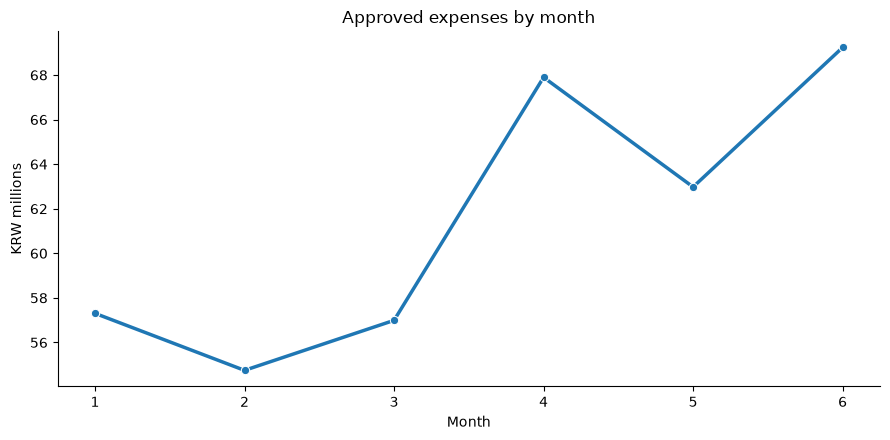

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=monthly_summary, x="month", y="amount_krw", marker="o", linewidth=2.5, ax=ax)
ax.set_xticks(monthly_summary["month"])
ax.set(title="Approved expenses by month", xlabel="Month", ylabel="KRW millions")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}"))
sns.despine()
fig.tight_layout()
fig.savefig("outputs/monthly_spend_en.png", dpi=180, bbox_inches="tight")
plt.show()


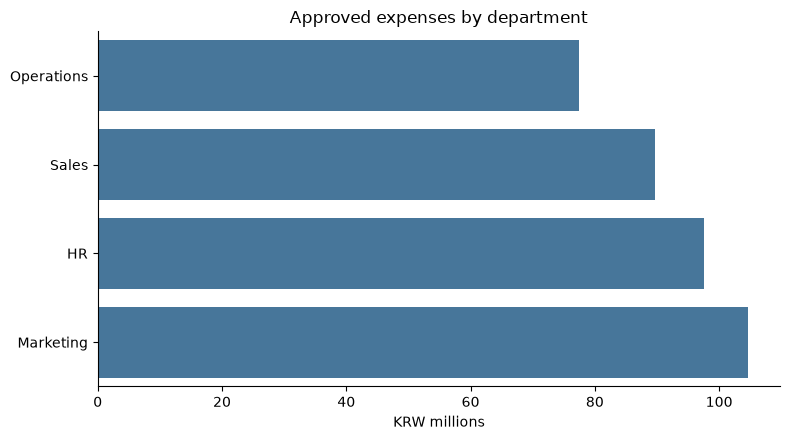

In [44]:
department_totals = (
    approved.groupby("department", as_index=False)["amount_krw"]
    .sum()
    .sort_values("amount_krw", ascending=True)
)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=department_totals, x="amount_krw", y="department", color="#3978A8", ax=ax)
ax.set(title="Approved expenses by department", xlabel="KRW millions", ylabel="")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}"))
sns.despine()
fig.tight_layout()
fig.savefig("outputs/department_spend_en.png", dpi=180, bbox_inches="tight")
plt.show()


 ## 9. Reuse results for Korean output

In [45]:
DEPARTMENT_KR = {"Marketing": "마케팅", "Sales": "영업", "Operations": "운영", "HR": "인사"}
CATEGORY_KR = {
    "Advertising": "광고비", "Software": "소프트웨어", "Travel": "출장비",
    "Meals": "식비", "Client Events": "고객행사", "Office Supplies": "사무용품",
    "Logistics": "물류비", "Training": "교육비", "Recruiting": "채용비",
}

department_summary_kr = department_summary.copy()
department_summary_kr["department"] = department_summary_kr["department"].replace(DEPARTMENT_KR)
department_summary_kr["category"] = department_summary_kr["category"].replace(CATEGORY_KR)
department_summary_kr = department_summary_kr.rename(columns={
    "department": "부서", "category": "항목", "amount_krw": "금액(원)"
})

print(department_summary_kr.head())

     부서    항목       금액(원)
12   영업  고객행사  62984000.0
4   마케팅   광고비  58935000.0
2    인사   채용비  53879000.0
11   운영   교육비  34902000.0
3    인사   교육비  32519000.0


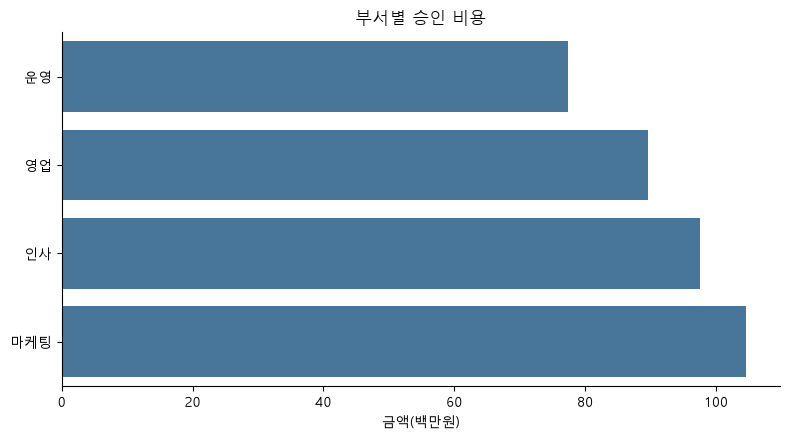

In [46]:
department_totals_kr = department_totals.copy()
department_totals_kr["department"] = department_totals_kr["department"].replace(DEPARTMENT_KR)

plt.rc('font', family=['Malgun Gothic', 'sans-serif'])


fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=department_totals_kr, x="amount_krw", y="department", color="#3978A8", ax=ax)
ax.set(title="부서별 승인 비용", xlabel="금액(백만원)", ylabel="")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}"))
sns.despine()
fig.tight_layout()
fig.savefig("outputs/department_spend_kr.png", dpi=180, bbox_inches="tight")
plt.show()


In [47]:
## Save the cleaned and transformed expenses to one Excel
transformed_df.to_excel(output_dir / "clean_expenses.xlsx", index=False)

## Then save the summary of expenses to separate Excel files for English and Korean versions

with pd.ExcelWriter(output_dir / "expense_summary_en.xlsx") as writer:
    monthly_summary.to_excel(writer, sheet_name="Monthly", index=False)
    department_summary.to_excel(writer, sheet_name="Department category", index=False)

with pd.ExcelWriter(output_dir / "expense_summary_kr.xlsx") as writer:
    monthly_summary.rename(columns={"month": "월", "amount_krw": "금액(원)"}).to_excel(
        writer, sheet_name="월별", index=False
    )
    department_summary_kr.to_excel(writer, sheet_name="부서_항목", index=False)


 ## 10. Export this script to a Python file



 Now that your Notebook is tested and working correctly, you can export it to a Python file for further use or deployment.



 - Open the VS Code command palette (Ctrl+Shift+P or Cmd+Shift+P on Mac).

 - Search for "Jupyter: Export to Python Script"

 - A new editor tab will open with the exported Python script.

 - Save the file to your desired location, for example `process_spendings.py`



 Now delete all the output in the outputs folder and run the exported Python script to regenerate the outputs.

 ## Doom scenario



 It's Friday 5:30pm and your manager walks into your office, pretty excited that he just received the monthly expense reports of June...



 How long will it take you to add these numbers to the reports and charts?

 drop the June files in data/inbox , run the exported script (or Restart → Run All), then
check unique() for any new spelling that became NaN. In our earlier June test the table grew from 448 to 539 rows
and approved spending Jan–Jun was 369,158,000 KRW — minutes, not hours, because nothing was hard-coded.